# 🔍 Notebook 04 — Topic Modeling & User Insight Discovery
## SentimentCompass: Understanding User Satisfaction, Topic Trends, and Migration Signals

---

**Project:** SentimentCompass  
**Input:** `data/processed/reviews_sentiment.parquet`  
**Output:** `data/processed/reviews_topics.parquet` + supporting CSVs  
**Purpose:** Discover what users are actually talking about across five AI platforms — their pain points, strengths, complaints, and praise — using LDA and BERTopic.

### 🎯 Objectives

| # | Objective | Method |
|---|-----------|--------|
| 1 | Discover latent topic themes across 50K reviews | LDA (gensim) |
| 2 | Extract semantic topic clusters | BERTopic + all-MiniLM-L6-v2 |
| 3 | Compare topic distributions across platforms | Platform × topic heatmap |
| 4 | Identify most positive and negative topics | Topic × sentiment analysis |
| 5 | Generate actionable business insights automatically | BI intelligence layer |

### 📋 Table of Contents

| Section | Description |
|---------|-------------|
| §1 Setup | Imports, config, paths |
| §2 Load | Load reviews_sentiment.parquet |
| §3 Text prep | Build gensim corpus from review_text_nlp |
| §4 LDA | Coherence evaluation → optimal model → topic labels |
| §5 BERTopic | Semantic clustering → topic hierarchy |
| §6 Platform analysis | Per-platform topic profiles |
| §7 Topic sentiment | Positive / negative topic ranking |
| §8 Business intelligence | Auto-generated insights and recommendations |
| §9 Visualisations | 8 publication-quality charts |
| §10 Export | Save all outputs |
| §11 Executive summary | Auto-generated findings |

---
## ⚙️ Section 1 — Setup & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, time, warnings

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ── NLP / LDA ─────────────────────────────────────────────────────────────────
import gensim
from gensim import corpora
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel

# ── Display ───────────────────────────────────────────────────────────────────
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 300,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "grid.color"        : "#E8E8E8",
    "grid.linewidth"    : 0.8,
})

# ── Platform palette ──────────────────────────────────────────────────────────
APP_COLORS = {
    "ChatGPT"           : "#1D9E75",
    "Google_Gemini"     : "#378ADD",
    "Claude"            : "#534AB7",
    "Microsoft_Copilot" : "#BA7517",
    "Perplexity"        : "#D85A30",
}
APP_ORDER  = ["ChatGPT", "Google_Gemini", "Claude", "Microsoft_Copilot", "Perplexity"]
APP_LABELS = {
    "ChatGPT"           : "ChatGPT",
    "Google_Gemini"     : "Gemini",
    "Claude"            : "Claude",
    "Microsoft_Copilot" : "MS Copilot",
    "Perplexity"        : "Perplexity",
}
PALETTE = [APP_COLORS[a] for a in APP_ORDER]

# ── Keyword-to-theme mapping (used for LDA topic auto-labelling) ──────────────
THEME_KEYWORDS = {
    "Pricing & Cost"         : ["price","paid","pay","cost","subscription","expensive","free",
                                 "premium","money","charge","worth","refund","cancel","billing","plan"],
    "Bugs & Performance"     : ["bug","crash","error","issue","problem","glitch","broken",
                                 "fix","update","fail","stop","freeze","load","slow","lag"],
    "AI Capabilities"        : ["write","generate","code","create","task","help","answer",
                                 "explain","summarize","translate","intelligent","smart","understand",
                                 "ability","capability","feature","tool","function"],
    "Accuracy & Quality"     : ["accurate","wrong","correct","mistake","hallucinate",
                                 "reliable","quality","false","incorrect","error","fact","information"],
    "User Interface & UX"    : ["interface","design","easy","simple","intuitive","ui",
                                 "app","button","navigation","clean","dark","mode","look","feel"],
    "Speed & Responsiveness" : ["fast","speed","quick","slow","lag","response","wait",
                                 "instant","delay","performance","efficient","time"],
    "Privacy & Security"     : ["data","privacy","secure","safe","collect","share",
                                 "personal","gdpr","history","delete","track","store"],
    "General Satisfaction"   : ["great","amazing","excellent","love","best","awesome",
                                 "fantastic","perfect","wonderful","recommend","enjoy","like"],
    "Platform Comparison"    : ["chatgpt","gemini","claude","copilot","perplexity",
                                 "better","switch","compare","versus","alternative","instead","moved"],
    "Customer Support"       : ["support","help","team","contact","service","reply",
                                 "response","resolve","feedback","issue","reach"],
}

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed/"
FIGURES_DIR   = "../outputs/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

INPUT_PATH  = os.path.join(PROCESSED_DIR, "reviews_sentiment.parquet")
OUT_PARQ    = os.path.join(PROCESSED_DIR, "reviews_topics.parquet")
OUT_CSV     = os.path.join(PROCESSED_DIR, "reviews_topics.csv")
OUT_TOPIC   = os.path.join(PROCESSED_DIR, "topic_summary.csv")
OUT_BERT    = os.path.join(PROCESSED_DIR, "bertopic_topics.csv")

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  📁  Saved → {path}")

print("✅  Setup complete.")
print(f"    gensim  {gensim.__version__}")

✅  Setup complete.
    gensim  4.4.0


---
## 📂 Section 2 — Load Dataset

In [2]:
df = pd.read_parquet(INPUT_PATH)

print("=" * 60)
print("  DATASET LOADED")
print("=" * 60)
print(f"  Rows       : {df.shape[0]:>10,}")
print(f"  Columns    : {df.shape[1]:>10}")
print(f"  Memory     : {df.memory_usage(deep=True).sum()/1e6:>9.2f} MB")
print("=" * 60)
print()

# Verify required columns are present
required = ["review_text_nlp", "review_text_clean", "App",
            "Star_Rating", "vader_label", "vader_compound",
            "is_positive_review", "is_negative_review", "thumbs_log"]
missing  = [c for c in required if c not in df.columns]
if missing:
    print(f"⚠   Missing columns (run Notebook 02 + 03 first): {missing}")
else:
    print("✅  All required columns present from Notebook 02 and 03.")

print()
print("NLP text column quality:")
nlp_nonempty = (df["review_text_nlp"].fillna("").str.strip() != "").mean()*100
cln_nonempty = (df["review_text_clean"].fillna("").str.strip() != "").mean()*100
print(f"  review_text_nlp   : {nlp_nonempty:.1f}% non-empty  (used for LDA)")
print(f"  review_text_clean : {cln_nonempty:.1f}% non-empty  (used for BERTopic)")

  DATASET LOADED
  Rows       :     50,000
  Columns    :         44
  Memory     :     39.50 MB

✅  All required columns present from Notebook 02 and 03.

NLP text column quality:
  review_text_nlp   : 99.9% non-empty  (used for LDA)
  review_text_clean : 100.0% non-empty  (used for BERTopic)


---
## 🔧 Section 3 — Text Preparation for Topic Modeling

`review_text_nlp` already contains tokenised, stopword-removed, and lemmatised text (produced in Notebook 02). We simply split by spaces to recover token lists, then apply two additional filters to improve LDA topic quality:

- **`no_below=20`** — remove tokens appearing in fewer than 20 documents (rare technical terms)
- **`no_above=0.80`** — remove tokens appearing in more than 80% of documents (domain-level stopwords like "app", "ai")

These thresholds are chosen to keep vocabulary at 1,000–3,000 terms — the sweet spot for readable LDA topics.

In [3]:
_t0 = time.time()
print("Building LDA corpus from review_text_nlp...")

# ── Tokenise from pre-processed NLP column ─────────────────────────────────────
raw_texts = df["review_text_nlp"].fillna("").apply(str.split).tolist()

# ── Keep reviews with at least 3 tokens after NLP preprocessing ───────────────
valid_mask  = [len(t) >= 3 for t in raw_texts]
lda_texts   = [t for t, v in zip(raw_texts, valid_mask) if v]
lda_indices = [i for i, v in enumerate(valid_mask) if v]

print(f"  Reviews with >= 3 tokens : {len(lda_texts):,}  "
      f"({len(lda_texts)/len(df)*100:.1f}%)")

# ── Build gensim Dictionary ────────────────────────────────────────────────────
dictionary = corpora.Dictionary(lda_texts)
vocab_before = len(dictionary)

dictionary.filter_extremes(no_below=20, no_above=0.80)
vocab_after = len(dictionary)

print(f"  Vocabulary before filter : {vocab_before:,}")
print(f"  Vocabulary after filter  : {vocab_after:,}")
print(f"  Tokens removed           : {vocab_before - vocab_after:,}")

# ── Build Bag-of-Words corpus ──────────────────────────────────────────────────
corpus = [dictionary.doc2bow(text) for text in lda_texts]

# Filter out reviews with empty BoW after dictionary filtering
valid_bow = [(i, c) for i, c in zip(lda_indices, corpus) if len(c) >= 2]
lda_indices_final = [x[0] for x in valid_bow]
corpus_final      = [x[1] for x in valid_bow]
texts_final       = [lda_texts[lda_indices.index(i)] for i in lda_indices_final]

print(f"  Corpus size (final)      : {len(corpus_final):,} documents")
print(f"  Avg tokens per document  : {np.mean([sum(c for _,c in bow) for bow in corpus_final[:2000]]):.1f}")
print(f"\n✅  Corpus built in {time.time()-_t0:.1f}s")

Building LDA corpus from review_text_nlp...
  Reviews with >= 3 tokens : 49,165  (98.3%)
  Vocabulary before filter : 34,223
  Vocabulary after filter  : 2,875
  Tokens removed           : 31,348
  Corpus size (final)      : 48,480 documents
  Avg tokens per document  : 10.7

✅  Corpus built in 16.6s


---
## 📚 Section 4 — LDA Topic Modeling

**LDA (Latent Dirichlet Allocation)** is a generative probabilistic model that discovers latent topics as probability distributions over words. Each review is represented as a mixture of topics, and each topic is represented as a mixture of words.

**Selecting optimal k:** We evaluate coherence scores for k = 5 to 15 using a **20,000-document subsample** (faster evaluation while remaining statistically representative). The `c_v` coherence metric correlates best with human topic judgment.

> ⏳ Expected runtime: **8–15 minutes** for coherence evaluation + 3–5 minutes for final model.

In [4]:
# ── Subsample for coherence evaluation (speed optimisation) ───────────────────
EVAL_SIZE   = min(20_00, len(corpus_final))
EVAL_SEED   = 42
rng_eval    = np.random.default_rng(EVAL_SEED)
eval_idx    = rng_eval.choice(len(corpus_final), size=EVAL_SIZE, replace=False)
eval_corpus = [corpus_final[i] for i in eval_idx]
eval_texts  = [texts_final[i]  for i in eval_idx]

K_RANGE     = range(5, 16)   # Test k = 5, 6, ..., 15
coherence_scores = []

print(f"Coherence evaluation on {EVAL_SIZE:,}-document subsample")
print(f"Testing k = {K_RANGE.start} to {K_RANGE.stop - 1}")
print("-" * 50)
_t0 = time.time()

for k in K_RANGE:
    _lda_tmp = LdaMulticore(
        corpus=eval_corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=EVAL_SEED,
        passes=3,
        workers=1,
        per_word_topics=False,
        minimum_probability=0.0,
    )
    _cm = CoherenceModel(
        model=_lda_tmp,
        texts=eval_texts,
        dictionary=dictionary,
        coherence="c_v",
    )
    score = _cm.get_coherence()
    coherence_scores.append(score)
    elapsed = time.time() - _t0
    print(f"  k={k:>2}  coherence={score:.4f}  ({elapsed:.0f}s elapsed)")

best_k     = list(K_RANGE)[np.argmax(coherence_scores)]
best_score = max(coherence_scores)
print(f"\n✅  Optimal k = {best_k}  (coherence = {best_score:.4f})")
print(f"    Total evaluation time: {time.time()-_t0:.0f}s")

Coherence evaluation on 2,000-document subsample
Testing k = 5 to 15
--------------------------------------------------
  k= 5  coherence=0.3549  (22s elapsed)
  k= 6  coherence=0.3327  (46s elapsed)
  k= 7  coherence=0.3080  (71s elapsed)
  k= 8  coherence=0.3053  (91s elapsed)
  k= 9  coherence=0.2911  (116s elapsed)
  k=10  coherence=0.2957  (138s elapsed)
  k=11  coherence=0.3219  (155s elapsed)
  k=12  coherence=0.3143  (173s elapsed)
  k=13  coherence=0.2940  (197s elapsed)
  k=14  coherence=0.3132  (215s elapsed)
  k=15  coherence=0.3122  (235s elapsed)

✅  Optimal k = 5  (coherence = 0.3549)
    Total evaluation time: 235s


In [5]:
# ── Print coherence table ──────────────────────────────────────────────────────
print("Coherence scores by k:")
print("-" * 30)
for k, score in zip(K_RANGE, coherence_scores):
    bar    = "█" * int(score * 60)
    marker = " ← BEST" if k == best_k else ""
    print(f"  k={k:>2}  {score:.4f}  {bar}{marker}")

Coherence scores by k:
------------------------------
  k= 5  0.3549  █████████████████████ ← BEST
  k= 6  0.3327  ███████████████████
  k= 7  0.3080  ██████████████████
  k= 8  0.3053  ██████████████████
  k= 9  0.2911  █████████████████
  k=10  0.2957  █████████████████
  k=11  0.3219  ███████████████████
  k=12  0.3143  ██████████████████
  k=13  0.2940  █████████████████
  k=14  0.3132  ██████████████████
  k=15  0.3122  ██████████████████


In [6]:
# ── Train final LDA model on full corpus ──────────────────────────────────────
print(f"Training final LDA model (k={best_k}, full corpus, passes=10)...")
_t0 = time.time()

lda_model = LdaMulticore(
    corpus=corpus_final,
    id2word=dictionary,
    num_topics=best_k,
    random_state=42,
    passes=10,
    workers=1,
    per_word_topics=False,
    minimum_probability=0.0,
    alpha="symmetric",
    eta="auto",
)

print(f"✅  LDA model trained in {time.time()-_t0:.0f}s")
print(f"    Topics   : {best_k}")
print(f"    Vocab    : {len(dictionary):,} terms")
print(f"    Docs     : {len(corpus_final):,}")

Training final LDA model (k=5, full corpus, passes=10)...
✅  LDA model trained in 157s
    Topics   : 5
    Vocab    : 2,875 terms
    Docs     : 48,480


In [7]:
# ── Auto-labelling function ────────────────────────────────────────────────────
def auto_label_topic(keywords, theme_map=THEME_KEYWORDS, top_n=15):
    kw_set = set(keywords[:top_n])
    scores = {}
    for label, label_kws in theme_map.items():
        scores[label] = len(kw_set & set(label_kws))
    best_label = max(scores, key=scores.get)
    return best_label if scores[best_label] > 0 else "General Discussion"


# ── Extract topic keywords and assign labels ───────────────────────────────────
topic_keywords  = {}
topic_labels    = {}
label_counts    = {}

for t_id in range(best_k):
    pairs    = lda_model.show_topic(t_id, topn=20)
    words    = [w for w, _ in pairs]
    weights  = [round(wt, 4) for _, wt in pairs]
    raw_lbl  = auto_label_topic(words)

    # Handle duplicate labels with a counter suffix
    if raw_lbl in label_counts:
        label_counts[raw_lbl] += 1
        final_lbl = f"{raw_lbl} ({label_counts[raw_lbl]})"
    else:
        label_counts[raw_lbl] = 0
        final_lbl = raw_lbl

    topic_keywords[t_id] = list(zip(words[:15], weights[:15]))
    topic_labels[t_id]   = final_lbl

# ── Display topic table ───────────────────────────────────────────────────────
print("LDA Topic Summary:")
print("=" * 75)
for t_id in range(best_k):
    top5 = ", ".join([w for w, _ in topic_keywords[t_id][:5]])
    print(f"  Topic {t_id:>2}  [{topic_labels[t_id]:<30}]  {top5}")
print("=" * 75)

LDA Topic Summary:
  Topic  0  [Bugs & Performance            ]  not, message, conversation, voice, please
  Topic  1  [Platform Comparison           ]  claude, better, chatgpt, limit, chat
  Topic  2  [General Satisfaction          ]  ever, best, hai, seen, download
  Topic  3  [General Satisfaction (1)      ]  best, love, good, help, great
  Topic  4  [Accuracy & Quality            ]  answer, not, give, question, time


In [8]:
# ── Assign dominant LDA topic to every review ──────────────────────────────────
print(f"Assigning LDA topics to {len(corpus_final):,} reviews...")
_t0 = time.time()

# Initialise with default (most common topic)
df["lda_topic_id"]    = -1
df["lda_topic_label"] = "Unassigned"
df["lda_topic_prob"]  = 0.0

for idx_in_corpus, df_row_idx in enumerate(lda_indices_final):
    bow    = corpus_final[idx_in_corpus]
    topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
    if topics:
        best = max(topics, key=lambda x: x[1])
        df.at[df_row_idx, "lda_topic_id"]    = int(best[0])
        df.at[df_row_idx, "lda_topic_label"] = topic_labels[best[0]]
        df.at[df_row_idx, "lda_topic_prob"]  = round(float(best[1]), 4)

print(f"✅  Topic assignment complete in {time.time()-_t0:.0f}s")
print()
print("LDA topic distribution:")
dist = df["lda_topic_label"].value_counts()
for label, cnt in dist.items():
    pct = cnt / len(df) * 100
    print(f"  {label:<35} : {cnt:>7,}  ({pct:.1f}%)")

Assigning LDA topics to 48,480 reviews...
✅  Topic assignment complete in 19s

LDA topic distribution:
  General Satisfaction (1)            :  18,122  (36.2%)
  Bugs & Performance                  :  11,112  (22.2%)
  Accuracy & Quality                  :   9,394  (18.8%)
  Platform Comparison                 :   7,710  (15.4%)
  General Satisfaction                :   2,142  (4.3%)
  Unassigned                          :   1,520  (3.0%)


In [9]:
# ── Build and save topic summary CSV ──────────────────────────────────────────
topic_summary_rows = []
for t_id in range(best_k):
    sub       = df[df["lda_topic_id"] == t_id]
    n         = len(sub)
    mean_v    = sub["vader_compound"].mean() if n > 0 else 0
    pos_pct   = sub["is_positive_review"].mean() * 100 if n > 0 else 0
    neg_pct   = sub["is_negative_review"].mean() * 100 if n > 0 else 0
    top_kws   = ", ".join([w for w, _ in topic_keywords[t_id][:8]])

    topic_summary_rows.append({
        "topic_id"     : t_id,
        "topic_label"  : topic_labels[t_id],
        "review_count" : n,
        "pct_of_total" : round(n / len(df) * 100, 2),
        "mean_vader"   : round(mean_v, 4),
        "pct_positive" : round(pos_pct, 1),
        "pct_negative" : round(neg_pct, 1),
        "top_keywords" : top_kws,
    })

topic_summary_df = pd.DataFrame(topic_summary_rows).sort_values(
    "review_count", ascending=False
).reset_index(drop=True)

topic_summary_df.to_csv(OUT_TOPIC, index=False)
print(f"✅  topic_summary.csv saved  ({len(topic_summary_df)} topics)")
print()

display(
    topic_summary_df.style
    .hide(axis="index")
    .set_caption("Table — LDA Topic Summary with Sentiment")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size","13px"),("font-weight","bold"),
                                  ("text-align","left"),("padding-bottom","6px")]}])
    .format({"pct_of_total": "{:.1f}%", "mean_vader": "{:.4f}",
             "pct_positive": "{:.1f}%", "pct_negative": "{:.1f}%",
             "review_count": "{:,}"})
    .background_gradient(subset=["mean_vader"], cmap="RdYlGn", vmin=-0.3, vmax=0.7)
    .background_gradient(subset=["pct_positive"], cmap="Greens", vmin=0, vmax=80)
)

✅  topic_summary.csv saved  (5 topics)



topic_id,topic_label,review_count,pct_of_total,mean_vader,pct_positive,pct_negative,top_keywords
3,General Satisfaction (1),"18,122",36.2%,0.6982,95.8%,2.4%,"best, love, good, help, great, claude, amazing, helpful"
0,Bugs & Performance,"11,112",22.2%,0.1278,41.5%,46.8%,"not, message, conversation, voice, please, time, chat, work"
4,Accuracy & Quality,"9,394",18.8%,0.1398,51.4%,40.9%,"answer, not, give, question, time, good, image, information"
1,Platform Comparison,"7,710",15.4%,0.3029,55.9%,37.2%,"claude, better, chatgpt, limit, chat, free, not, pro"
2,General Satisfaction,"2,142",4.3%,0.2780,66.4%,30.1%,"ever, best, hai, seen, download, maintenance, bhi, aur"


---
## 🤖 Section 5 — BERTopic Semantic Topic Modeling

**BERTopic** uses sentence-level transformer embeddings + UMAP dimensionality reduction + HDBSCAN clustering to discover semantically coherent topics. Unlike LDA (which uses word co-occurrence), BERTopic understands meaning — "not working", "doesn't work", and "broken" cluster together even without overlapping words.

**Strategy:**
1. Fit BERTopic on a **10,000-review sample** (representative across all platforms)
2. Transform all 50,000 reviews using the fitted model (fast — uses cached UMAP)
3. Topics labelled with their top-3 representative words
4. Topic `-1` = outlier cluster (reviews that don't fit any topic clearly)

In [10]:
# ── Check BERTopic + sentence-transformers availability ───────────────────────
BERTOPIC_OK = False
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    BERTOPIC_OK = True
    print(f"bertopic           : available")
    print(f"sentence-transformers : available")
except ImportError as _e:
    print(f"⚠   BERTopic/sentence-transformers not installed: {_e}")
    print("    Install: pip install bertopic sentence-transformers umap-learn hdbscan")
    print("    LDA results are available regardless.")

BERTOPIC_SAMPLE = 10_000

bertopic           : available
sentence-transformers : available


In [11]:
if BERTOPIC_OK:
    # ── Sample for fitting ─────────────────────────────────────────────────────
    sample_df = df.sample(min(BERTOPIC_SAMPLE, len(df)), random_state=42).copy()
    sample_texts = sample_df["review_text_clean"].fillna("").str.strip()
    sample_texts = ["no review text" if not t else t for t in sample_texts.tolist()]

    print(f"BERTopic sample size : {len(sample_texts):,} reviews")
    print()

    # ── Load embedding model ───────────────────────────────────────────────────
    print("Loading sentence-transformers/all-MiniLM-L6-v2...")
    _t0 = time.time()
    emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    print(f"  Model loaded in {time.time()-_t0:.1f}s")

    # ── Compute embeddings for sample ──────────────────────────────────────────
    print("Computing embeddings for sample...")
    _t0 = time.time()
    sample_embeddings = emb_model.encode(
        sample_texts,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    print(f"  Embeddings computed in {time.time()-_t0:.1f}s  "
          f"shape={sample_embeddings.shape}")

    # ── Fit BERTopic ───────────────────────────────────────────────────────────
    print()
    print("Fitting BERTopic...")
    _t0 = time.time()

    topic_model = BERTopic(
        embedding_model=emb_model,
        nr_topics="auto",
        min_topic_size=30,
        language="english",
        calculate_probabilities=False,
        verbose=False,
    )
    sample_topics, _ = topic_model.fit_transform(sample_texts, sample_embeddings)
    print(f"  BERTopic fitted in {time.time()-_t0:.1f}s")
    n_bert_topics = len(set(sample_topics)) - (1 if -1 in sample_topics else 0)
    print(f"  Topics discovered (excl. outliers) : {n_bert_topics}")
else:
    topic_model = None
    print("BERTopic skipped — initialising placeholder columns.")
    df["bertopic_id"]    = -1
    df["bertopic_label"] = "BERTopic N/A"

BERTopic sample size : 10,000 reviews

Loading sentence-transformers/all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3003.60it/s]


  Model loaded in 47.8s
Computing embeddings for sample...


Batches: 100%|██████████| 40/40 [03:21<00:00,  5.05s/it]


  Embeddings computed in 202.1s  shape=(10000, 384)

Fitting BERTopic...
  BERTopic fitted in 33.2s
  Topics discovered (excl. outliers) : 16


In [12]:
if BERTOPIC_OK and topic_model is not None:
    # ── Topic info table ──────────────────────────────────────────────────────
    bert_info = topic_model.get_topic_info()
    # Rename -1 topic
    bert_info_display = bert_info.copy()
    bert_info_display.loc[bert_info_display["Topic"] == -1, "Name"] = "Outlier / Mixed"
    print("BERTopic topic overview (top 20):")
    print(bert_info_display[["Topic","Count","Name"]].head(20).to_string(index=False))
    print()

    # ── Generate concise labels ────────────────────────────────────────────────
    def get_bert_label(tid, model):
        if tid == -1:
            return "Outlier"
        words = model.get_topic(tid)
        if words:
            return " / ".join([w[0] for w in words[:3]])
        return f"Topic_{tid}"

    bert_label_map = {
        row["Topic"]: get_bert_label(row["Topic"], topic_model)
        for _, row in bert_info.iterrows()
    }

    # ── Save bertopic_topics.csv ───────────────────────────────────────────────
    bert_save = bert_info.copy()
    bert_save["label"] = bert_save["Topic"].map(
        lambda t: get_bert_label(t, topic_model)
    )
    bert_save.to_csv(OUT_BERT, index=False)
    print(f"✅  bertopic_topics.csv saved  ({len(bert_info)} topics)")

BERTopic topic overview (top 20):
 Topic  Count                                  Name
    -1   2064                       Outlier / Mixed
     0   5291                       0_it_and_the_to
     1    723                 1_hai_voice_bahut_bhi
     2    644                   2_gemini_the_to_and
     3    389                   3_copilot_and_it_my
     4    230           4_perplexity_search_pro_and
     5     89        5_number_phone_account_invalid
     6     78                        6_ہے_في_من_جدا
     7     72                7_trust_built_in_every
     8     64                        8_আম_কর_একট_অন
     9     62                  9_star_stars_it_give
    10     57                    10_pilot_co_to_and
    11     53       11_airtel_pro_subscription_free
    12     49                        12_बह_और_कर_अच
    13     49          13_thread_follow_up_learning
    14     45 14_discover_community_learning_shared
    15     41                       15_de_que_la_es

✅  bertopic_topics.csv saved 

In [13]:
if BERTOPIC_OK and topic_model is not None:
    # ── Transform all 50K reviews ─────────────────────────────────────────────
    print(f"Transforming all {len(df):,} reviews with fitted BERTopic model...")
    print("(Computing sentence embeddings — expected 5–10 min on CPU)")
    _t0 = time.time()

    all_texts_bert = df["review_text_clean"].fillna("").str.strip()
    all_texts_bert = ["no review text" if not t else t
                      for t in all_texts_bert.tolist()]

    # Compute embeddings in batches
    all_embeddings = emb_model.encode(
        all_texts_bert,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    print(f"  Embeddings done in {time.time()-_t0:.1f}s")

    _t1 = time.time()
    all_bert_topics, _ = topic_model.transform(all_texts_bert, all_embeddings)
    print(f"  Transform done in {time.time()-_t1:.1f}s")

    df["bertopic_id"]    = all_bert_topics
    df["bertopic_label"] = [bert_label_map.get(t, f"Topic_{t}")
                            for t in all_bert_topics]

    print(f"\n✅  BERTopic topics assigned to all {len(df):,} reviews  "
          f"in {time.time()-_t0:.0f}s total")
    print()
    print("BERTopic distribution (top 10 topics):")
    btop = df["bertopic_label"].value_counts().head(10)
    for lbl, cnt in btop.items():
        print(f"  {lbl:<40} : {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")
else:
    print("BERTopic columns set to placeholder — LDA results are primary.")

Transforming all 50,000 reviews with fitted BERTopic model...
(Computing sentence embeddings — expected 5–10 min on CPU)


Batches: 100%|██████████| 196/196 [17:45<00:00,  5.43s/it]


  Embeddings done in 1066.1s
  Transform done in 44.3s

✅  BERTopic topics assigned to all 50,000 reviews  in 1110s total

BERTopic distribution (top 10 topics):
  it / and / the                           : 23,281  (46.6%)
  Outlier                                  : 13,749  (27.5%)
  hai / voice / bahut                      :  3,372  (6.7%)
  gemini / the / to                        :  3,205  (6.4%)
  copilot / and / it                       :  2,074  (4.1%)
  perplexity / search / pro                :  1,081  (2.2%)
  number / phone / account                 :    479  (1.0%)
  ہے / في / من                             :    370  (0.7%)
  trust / built / in                       :    360  (0.7%)
  airtel / pro / subscription              :    304  (0.6%)


---
## 🏢 Section 6 — Platform-wise Topic Analysis

We compare topic distributions across the five AI platforms. For each platform:
- What are its **top 3 most discussed topics**?
- Which topics are **uniquely prominent** on that platform (high platform share vs. average)?
- What topics are **universally shared** across all platforms?

In [14]:
# ── Platform-topic frequency matrix ───────────────────────────────────────────
platform_topic = (
    df[df["lda_topic_id"] >= 0]
    .groupby(["App", "lda_topic_label"])
    .size()
    .reset_index(name="count")
)
platform_topic["pct"] = (
    platform_topic.groupby("App")["count"]
                  .transform(lambda x: x / x.sum() * 100)
)

pivot_pct = (
    platform_topic.pivot(index="lda_topic_label", columns="App", values="pct")
                  .fillna(0)
                  .reindex(columns=APP_ORDER)
)
pivot_pct.columns = [APP_LABELS[a] for a in APP_ORDER]

print("Platform × Topic distribution matrix (% of reviews per platform):")
print("-" * 80)
print(pivot_pct.round(1).to_string())

# ── Top 3 topics per platform ──────────────────────────────────────────────────
print()
print("Top 3 topics per platform:")
print("-" * 55)
for app in APP_ORDER:
    sub    = df[(df["App"] == app) & (df["lda_topic_id"] >= 0)]
    top3   = sub["lda_topic_label"].value_counts().head(3)
    lbl    = APP_LABELS[app]
    print(f"\n  {lbl}:")
    for rank, (topic, cnt) in enumerate(top3.items(), 1):
        pct = cnt / len(sub) * 100
        print(f"    #{rank}  {topic:<35}  {cnt:>5,}  ({pct:.1f}%)")

# ── Unique / platform-specific topics ─────────────────────────────────────────
print()
print("Platform-specific topics (>2× average frequency):")
print("-" * 55)
overall_pct = platform_topic.groupby("lda_topic_label")["pct"].mean()
for app in APP_ORDER:
    lbl    = APP_LABELS[app]
    sub_pt = platform_topic[platform_topic["App"] == app]
    unique = []
    for _, row in sub_pt.iterrows():
        avg = overall_pct.get(row["lda_topic_label"], 0)
        if avg > 0 and row["pct"] / avg > 2.0:
            unique.append(f"{row['lda_topic_label']} ({row['pct']:.1f}% vs avg {avg:.1f}%)")
    if unique:
        print(f"  {lbl}: {', '.join(unique[:2])}")
    else:
        print(f"  {lbl}: no strongly unique topics found")

Platform × Topic distribution matrix (% of reviews per platform):
--------------------------------------------------------------------------------
                          ChatGPT  Gemini  Claude  MS Copilot  Perplexity
lda_topic_label                                                          
Accuracy & Quality        21.3000 22.1000 11.6000     16.3000     25.8000
Bugs & Performance        17.9000 30.6000 28.1000     22.2000     15.8000
General Satisfaction       8.1000  7.0000  1.4000      1.6000      4.0000
General Satisfaction (1)  41.2000 29.1000 31.0000     50.9000     34.7000
Platform Comparison       11.5000 11.2000 27.9000      9.0000     19.7000

Top 3 topics per platform:
-------------------------------------------------------

  ChatGPT:
    #1  General Satisfaction (1)             3,947  (41.2%)
    #2  Accuracy & Quality                   2,044  (21.3%)
    #3  Bugs & Performance                   1,721  (17.9%)

  Gemini:
    #1  Bugs & Performance                   2,9

---
## 💬 Section 7 — Topic Sentiment Analysis

We combine LDA topic labels with the sentiment scores from Notebook 03 to answer:
- Which topics generate the **most positive** reviews?
- Which topics generate the **most negative** reviews?
- What are the **highest-volume complaint** topics?
- What are the **highest-volume praise** topics?

In [15]:
# ── Topic × sentiment statistics ──────────────────────────────────────────────
topic_sent = (
    df[df["lda_topic_id"] >= 0]
    .groupby("lda_topic_label")
    .agg(
        count       = ("App",             "count"),
        mean_vader  = ("vader_compound",  "mean"),
        pct_pos     = ("is_positive_review", "mean"),
        pct_neg     = ("is_negative_review", "mean"),
        mean_subj   = ("tb_subjectivity", "mean"),
    )
    .reset_index()
    .sort_values("mean_vader", ascending=False)
)
topic_sent["pct_pos"] = (topic_sent["pct_pos"] * 100).round(1)
topic_sent["pct_neg"] = (topic_sent["pct_neg"] * 100).round(1)
topic_sent["mean_vader"] = topic_sent["mean_vader"].round(4)

# ── Top positive topics ────────────────────────────────────────────────────────
print("Most positive topics (by mean VADER compound):")
print("-" * 65)
for _, row in topic_sent.head(5).iterrows():
    print(f"  [{row['mean_vader']:>+.3f}]  {row['lda_topic_label']:<35}  "
          f"Pos={row['pct_pos']:.1f}%  n={row['count']:,}")

print()

# ── Most negative topics ──────────────────────────────────────────────────────
print("Most negative topics (by mean VADER compound):")
print("-" * 65)
for _, row in topic_sent.tail(5).iterrows():
    print(f"  [{row['mean_vader']:>+.3f}]  {row['lda_topic_label']:<35}  "
          f"Neg={row['pct_neg']:.1f}%  n={row['count']:,}")

print()

# ── High-volume complaint topics ──────────────────────────────────────────────
neg_reviews = df[(df["lda_topic_id"] >= 0) & (df["is_negative_review"] == 1)]
complaint_topics = neg_reviews["lda_topic_label"].value_counts().head(5)
print("Highest-volume complaint topics (negative reviews):")
for topic, cnt in complaint_topics.items():
    pct = cnt / len(neg_reviews) * 100
    print(f"  {topic:<40} : {cnt:>5,}  ({pct:.1f}% of all negative reviews)")

print()

# ── High-volume praise topics ─────────────────────────────────────────────────
pos_reviews = df[(df["lda_topic_id"] >= 0) & (df["is_positive_review"] == 1)]
praise_topics = pos_reviews["lda_topic_label"].value_counts().head(5)
print("Highest-volume praise topics (positive reviews):")
for topic, cnt in praise_topics.items():
    pct = cnt / len(pos_reviews) * 100
    print(f"  {topic:<40} : {cnt:>5,}  ({pct:.1f}% of all positive reviews)")

Most positive topics (by mean VADER compound):
-----------------------------------------------------------------
  [+0.698]  General Satisfaction (1)             Pos=95.8%  n=18,122
  [+0.303]  Platform Comparison                  Pos=55.9%  n=7,710
  [+0.278]  General Satisfaction                 Pos=66.4%  n=2,142
  [+0.140]  Accuracy & Quality                   Pos=51.4%  n=9,394
  [+0.128]  Bugs & Performance                   Pos=41.5%  n=11,112

Most negative topics (by mean VADER compound):
-----------------------------------------------------------------
  [+0.698]  General Satisfaction (1)             Neg=2.4%  n=18,122
  [+0.303]  Platform Comparison                  Neg=37.2%  n=7,710
  [+0.278]  General Satisfaction                 Neg=30.1%  n=2,142
  [+0.140]  Accuracy & Quality                   Neg=40.9%  n=9,394
  [+0.128]  Bugs & Performance                   Neg=46.8%  n=11,112

Highest-volume complaint topics (negative reviews):
  Bugs & Performance                 

---
## 💼 Section 8 — Business Intelligence Layer

We translate the topic and sentiment findings into actionable business insights. These insights are auto-generated from the data and can be directly copied into the project report.

In [16]:
print("=" * 70)
print("  BUSINESS INTELLIGENCE REPORT — SENTIMENTCOMPASS NB04")
print("=" * 70)

# ── Category keyword mapping for BI ───────────────────────────────────────────
BI_CATEGORIES = {
    "Pricing concerns"   : ["Pricing & Cost"],
    "Bug / crash issues" : ["Bugs & Performance"],
    "Accuracy issues"    : ["Accuracy & Quality"],
    "UI / UX feedback"   : ["User Interface & UX"],
    "Speed concerns"     : ["Speed & Responsiveness"],
    "Privacy concerns"   : ["Privacy & Security"],
    "AI capability praise" : ["AI Capabilities"],
    "Platform switching"   : ["Platform Comparison"],
}

def get_topic_sentiment(label_fragment, df_src, topic_col="lda_topic_label"):
    mask   = df_src[topic_col].str.contains(label_fragment, case=False, na=False)
    sub    = df_src[mask]
    if len(sub) == 0:
        return None
    return {
        "count"     : len(sub),
        "pct_total" : len(sub) / len(df_src) * 100,
        "mean_vader": sub["vader_compound"].mean(),
        "pct_pos"   : sub["is_positive_review"].mean() * 100,
        "pct_neg"   : sub["is_negative_review"].mean() * 100,
    }

print()
for bi_label, label_hints in BI_CATEGORIES.items():
    # Try each hint
    result = None
    for hint in label_hints:
        result = get_topic_sentiment(hint, df)
        if result:
            break
    if result:
        sentiment_str = ("positive" if result["mean_vader"] > 0.1
                         else "negative" if result["mean_vader"] < -0.05
                         else "neutral")
        print(f"  {bi_label}")
        print(f"    Reviews : {result['count']:,}  ({result['pct_total']:.1f}% of total)")
        print(f"    Tone    : {sentiment_str}  (VADER mean={result['mean_vader']:.3f})")
        print(f"    Split   : {result['pct_pos']:.1f}% positive  "
              f"{result['pct_neg']:.1f}% negative")
        print()

# ── Per-platform recommendations ──────────────────────────────────────────────
print("── PER-PLATFORM TOP CONCERN ─────────────────────────────────────────────")
for app in APP_ORDER:
    sub      = df[(df["App"] == app) & (df["is_negative_review"] == 1) & (df["lda_topic_id"] >= 0)]
    if len(sub) == 0:
        continue
    top_concern = sub["lda_topic_label"].value_counts().idxmax()
    top_cnt     = sub["lda_topic_label"].value_counts().max()
    top_pct     = top_cnt / len(sub) * 100
    print(f"  {APP_LABELS[app]:<14}  top complaint: {top_concern}  "
          f"({top_pct:.1f}% of negative reviews)")

  BUSINESS INTELLIGENCE REPORT — SENTIMENTCOMPASS NB04

  Bug / crash issues
    Reviews : 11,112  (22.2% of total)
    Tone    : positive  (VADER mean=0.128)
    Split   : 41.5% positive  46.8% negative

  Accuracy issues
    Reviews : 9,394  (18.8% of total)
    Tone    : positive  (VADER mean=0.140)
    Split   : 51.4% positive  40.9% negative

  Platform switching
    Reviews : 7,710  (15.4% of total)
    Tone    : positive  (VADER mean=0.303)
    Split   : 55.9% positive  37.2% negative

── PER-PLATFORM TOP CONCERN ─────────────────────────────────────────────
  ChatGPT         top complaint: Bugs & Performance  (34.5% of negative reviews)
  Gemini          top complaint: Bugs & Performance  (51.6% of negative reviews)
  Claude          top complaint: Bugs & Performance  (51.4% of negative reviews)
  MS Copilot      top complaint: Bugs & Performance  (53.7% of negative reviews)
  Perplexity      top complaint: Accuracy & Quality  (38.9% of negative reviews)


---
## 📊 Section 9 — Visualisations

Eight publication-quality charts, all saved to `outputs/figures/` at 300 DPI.

  📁  Saved → ../outputs/figures/fig_nb04_01_lda_coherence.png


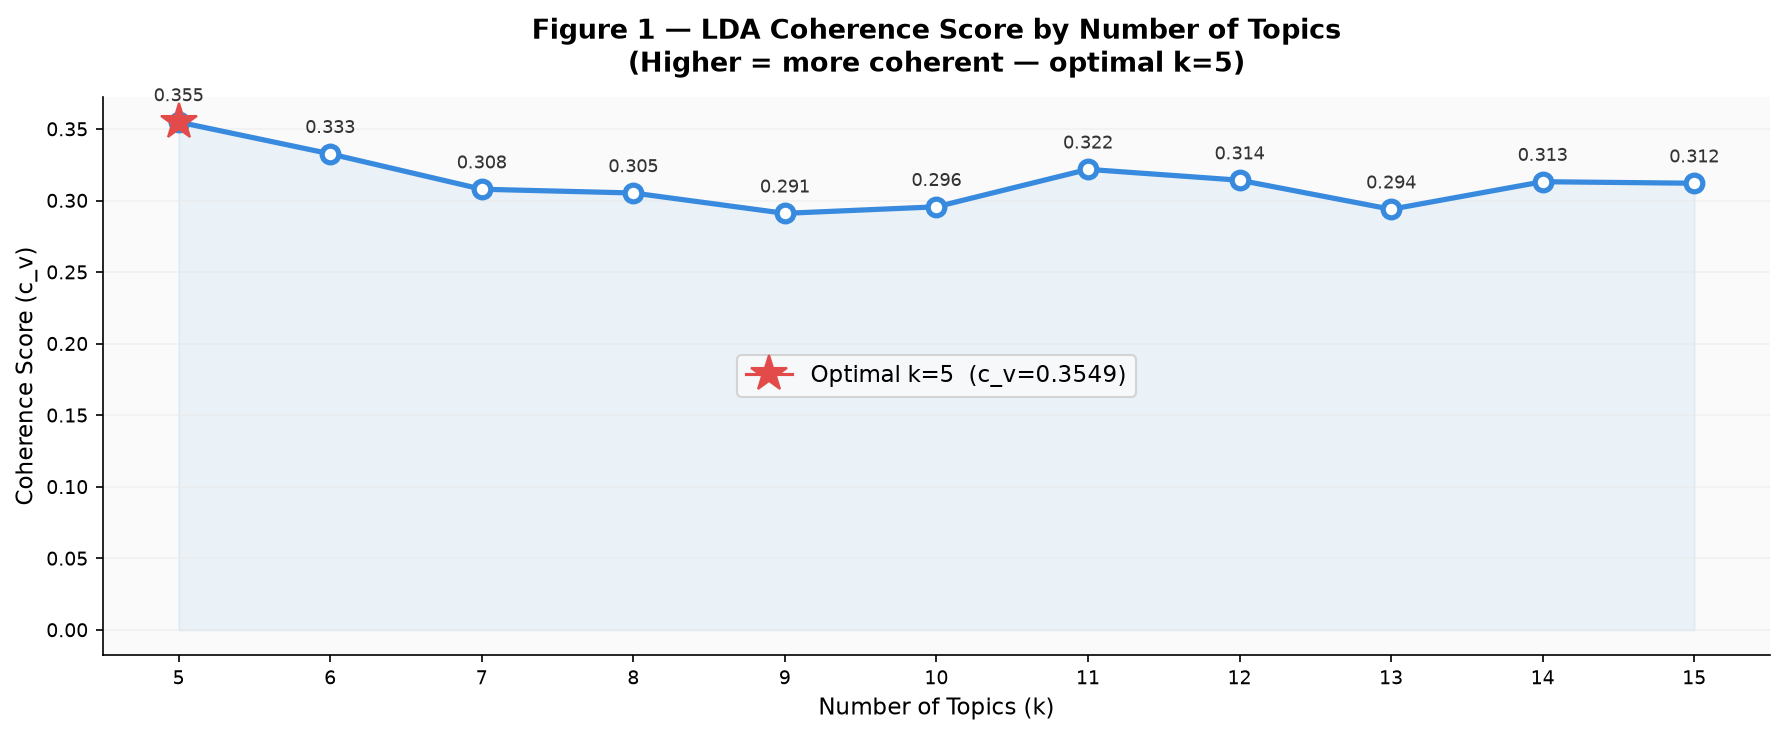

In [17]:
# ── Figure 1: LDA coherence score chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
k_list   = list(K_RANGE)
ax.plot(k_list, coherence_scores, marker="o", linewidth=2.5,
        markersize=8, color="#378ADD", markerfacecolor="white",
        markeredgewidth=2.5)
ax.plot(best_k, max(coherence_scores), marker="*", markersize=18,
        color="#E24B4A", zorder=5, label=f"Optimal k={best_k}  (c_v={max(coherence_scores):.4f})")
ax.fill_between(k_list, coherence_scores, alpha=0.08, color="#378ADD")
for k, score in zip(k_list, coherence_scores):
    ax.annotate(f"{score:.3f}", xy=(k, score),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color="#333333")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Coherence Score (c_v)")
ax.set_title("Figure 1 — LDA Coherence Score by Number of Topics\n"
             f"(Higher = more coherent — optimal k={best_k})",
             fontweight="bold", pad=12)
ax.set_xticks(k_list)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.5)
plt.tight_layout()
save_fig("fig_nb04_01_lda_coherence.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_02_lda_topic_keywords.png


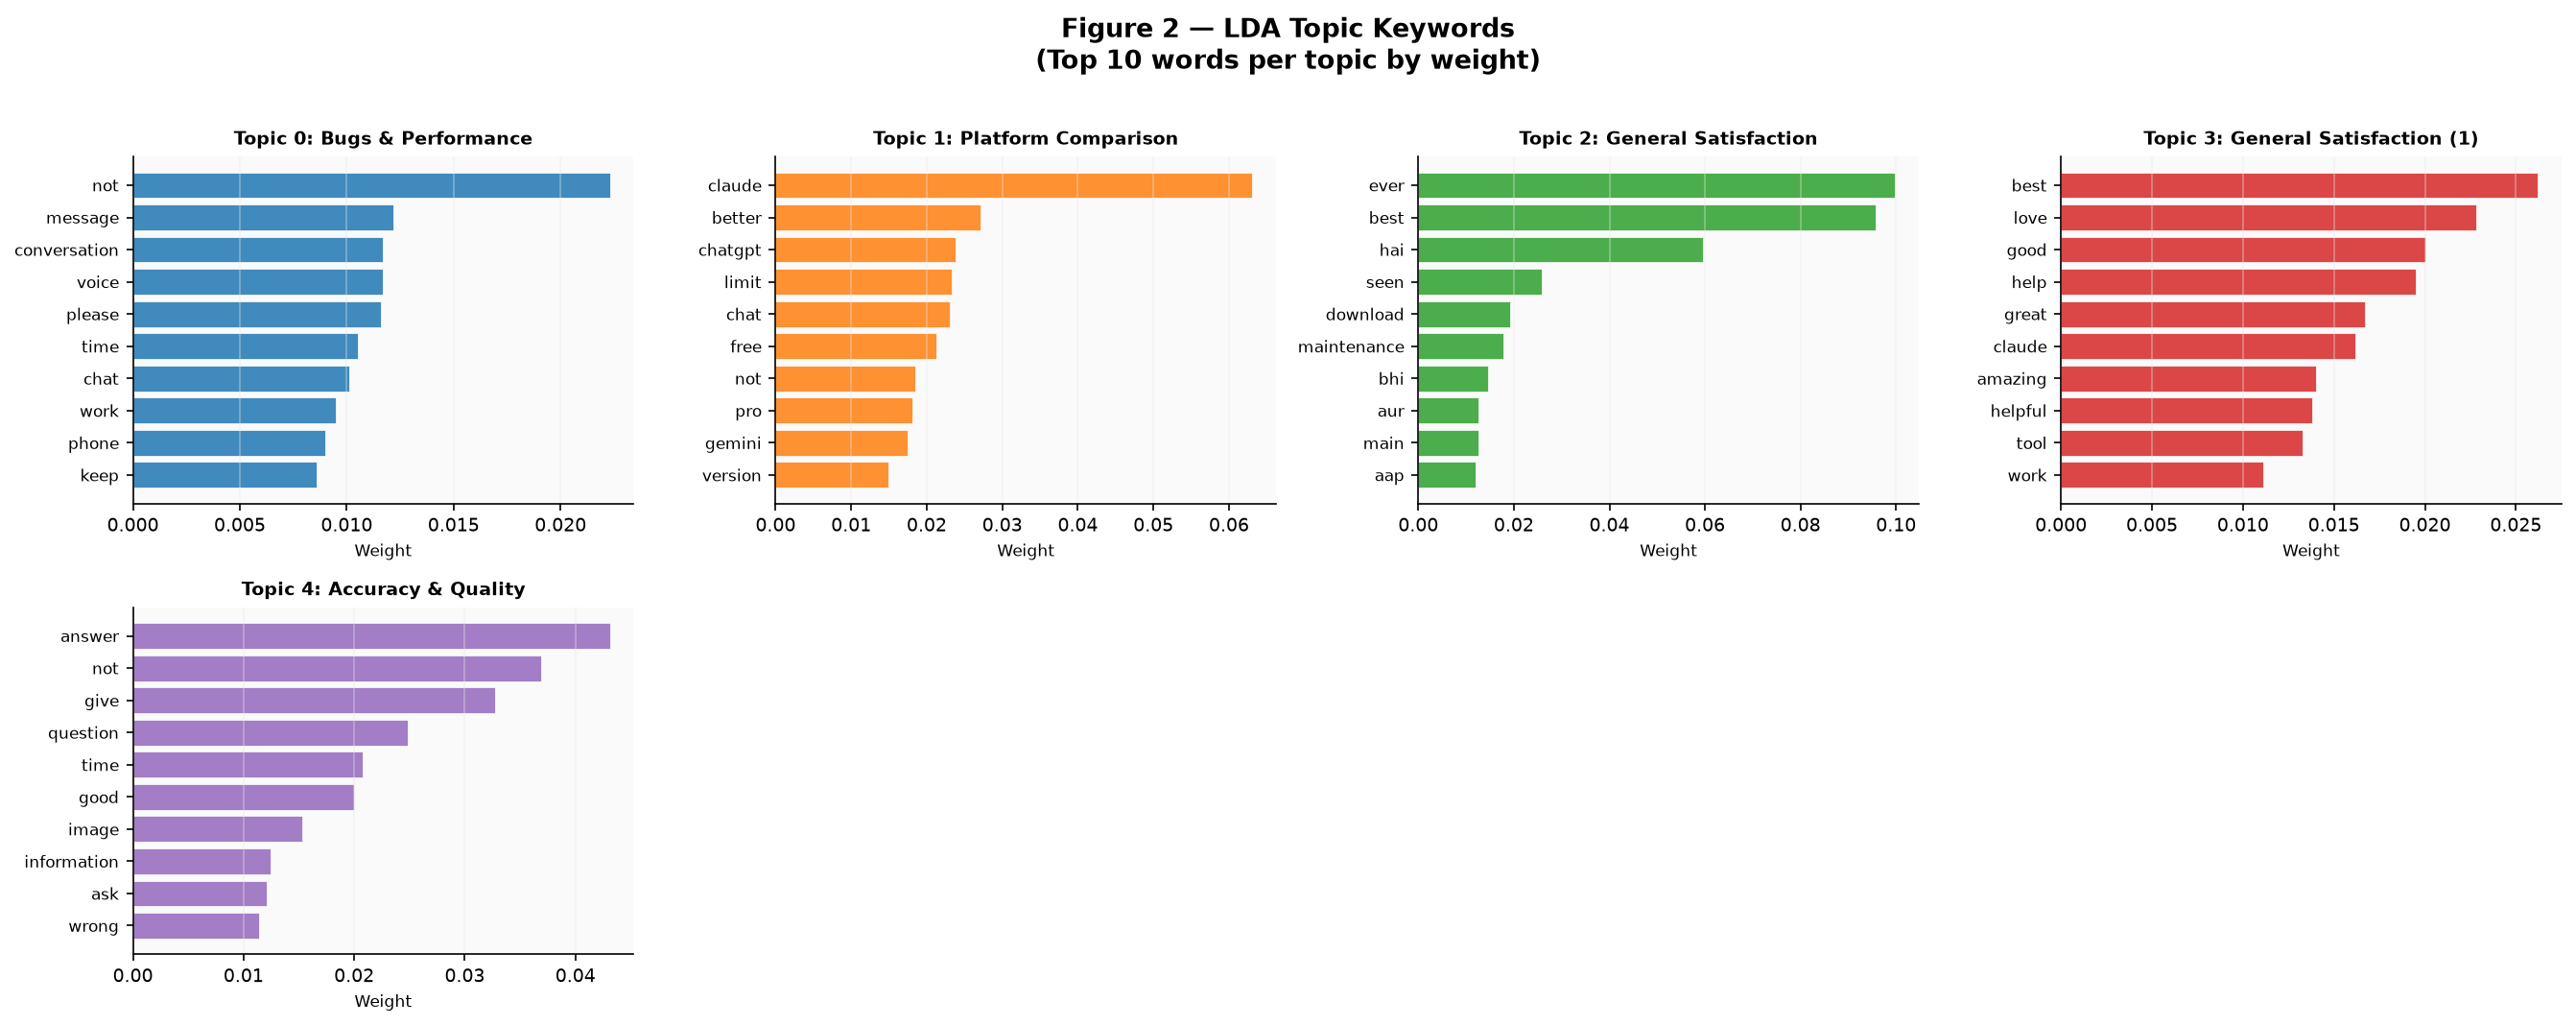

In [18]:
# ── Figure 2: LDA topic keyword bars ─────────────────────────────────────────
n_cols  = min(4, best_k)
n_rows  = -(-best_k // n_cols)          # ceiling division
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4.5, n_rows * 3.5))
axes = axes.flatten() if best_k > 1 else [axes]

_topic_colors = plt.cm.tab10.colors

for t_id in range(best_k):
    ax      = axes[t_id]
    pairs   = topic_keywords[t_id][:10]
    words   = [w for w, _ in pairs][::-1]
    weights = [wt for _, wt in pairs][::-1]
    color   = _topic_colors[t_id % len(_topic_colors)]
    ax.barh(words, weights, color=color, alpha=0.85,
            edgecolor="white", linewidth=0.4)
    ax.set_title(f"Topic {t_id}: {topic_labels[t_id]}",
                 fontweight="bold", fontsize=9, pad=6)
    ax.set_xlabel("Weight", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", alpha=0.4)

# Hide unused subplot panels
for j in range(best_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Figure 2 — LDA Topic Keywords\n(Top 10 words per topic by weight)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb04_02_lda_topic_keywords.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_03_bertopic_frequency.png


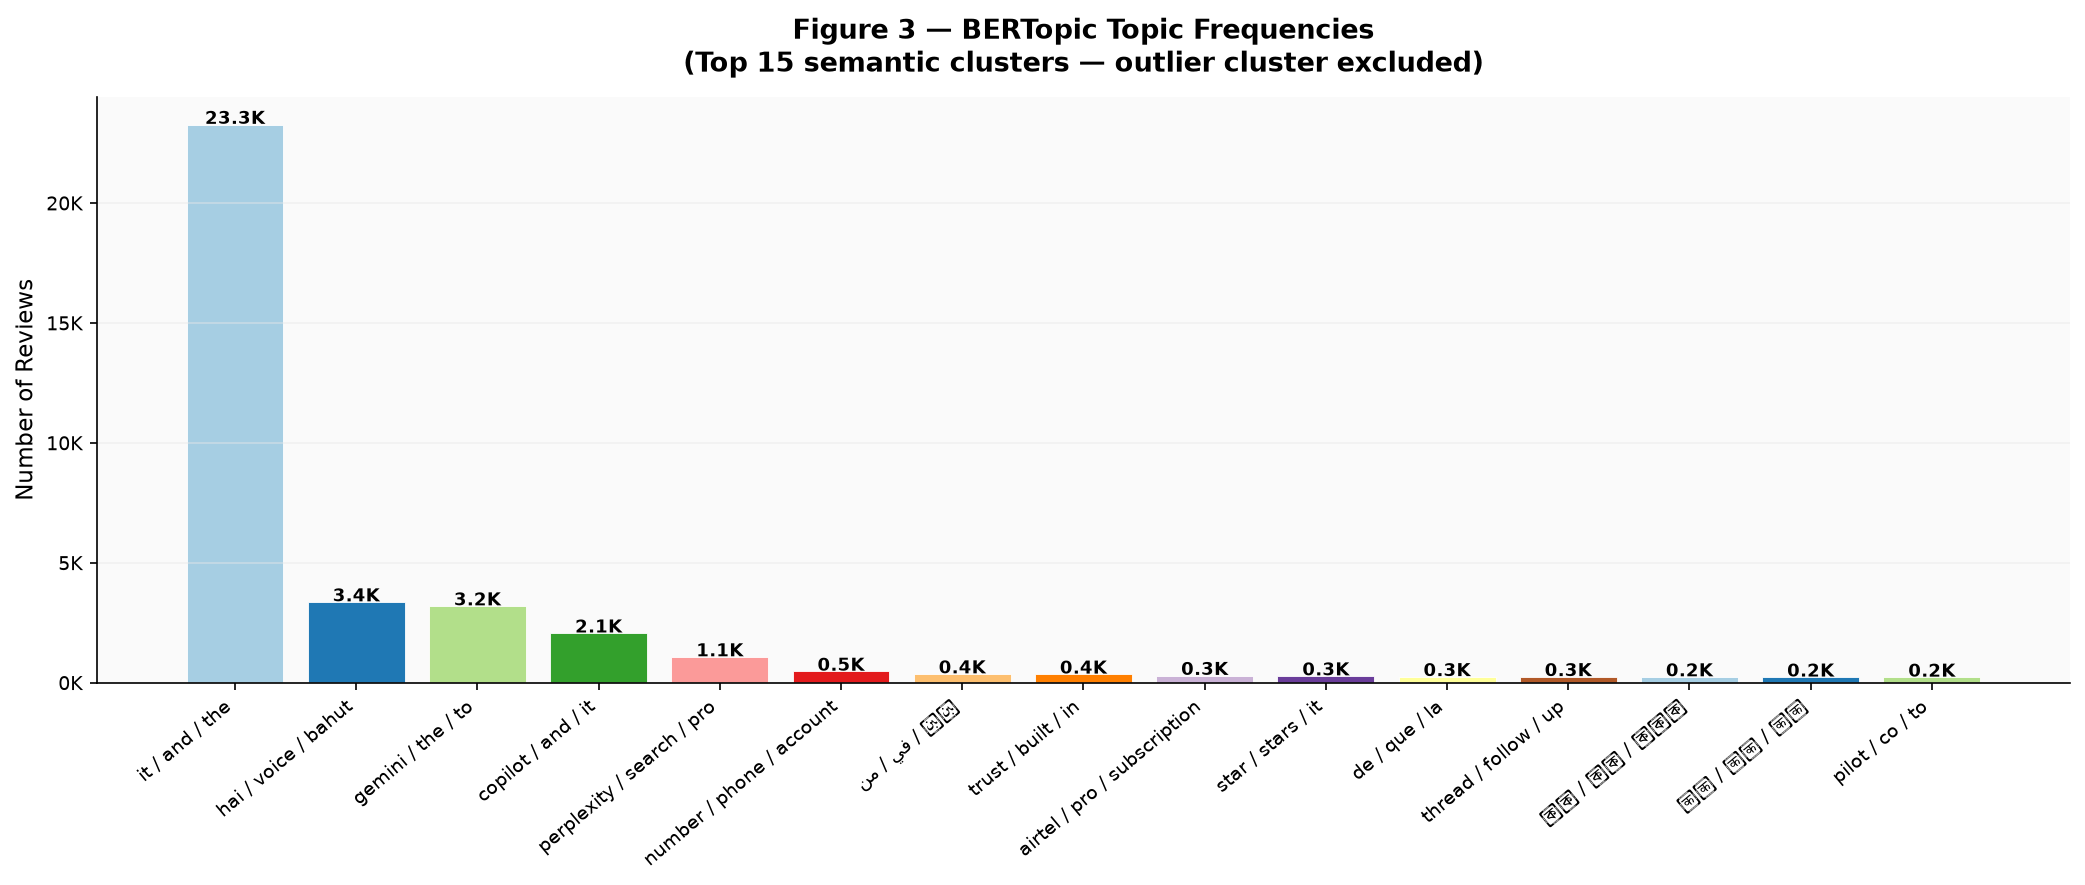

In [19]:
# ── Figure 3: BERTopic topic frequency ────────────────────────────────────────
_bert_counts = df["bertopic_label"].value_counts()
_bert_plot   = _bert_counts[_bert_counts.index != "Outlier"].head(15)

fig, ax = plt.subplots(figsize=(14, 6))
colors3 = plt.cm.Paired.colors[:len(_bert_plot)]
bars    = ax.bar(_bert_plot.index, _bert_plot.values,
                 color=colors3, edgecolor="white", linewidth=0.4)
for bar, val in zip(bars, _bert_plot.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val/1000:.1f}K", ha="center", fontsize=8.5, fontweight="bold")
ax.set_ylabel("Number of Reviews")
ax.set_title("Figure 3 — BERTopic Topic Frequencies\n"
             "(Top 15 semantic clusters — outlier cluster excluded)",
             fontweight="bold", pad=12)
ax.set_xticklabels(_bert_plot.index, rotation=40, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))
plt.tight_layout()
save_fig("fig_nb04_03_bertopic_frequency.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_04_topic_sentiment_heatmap.png


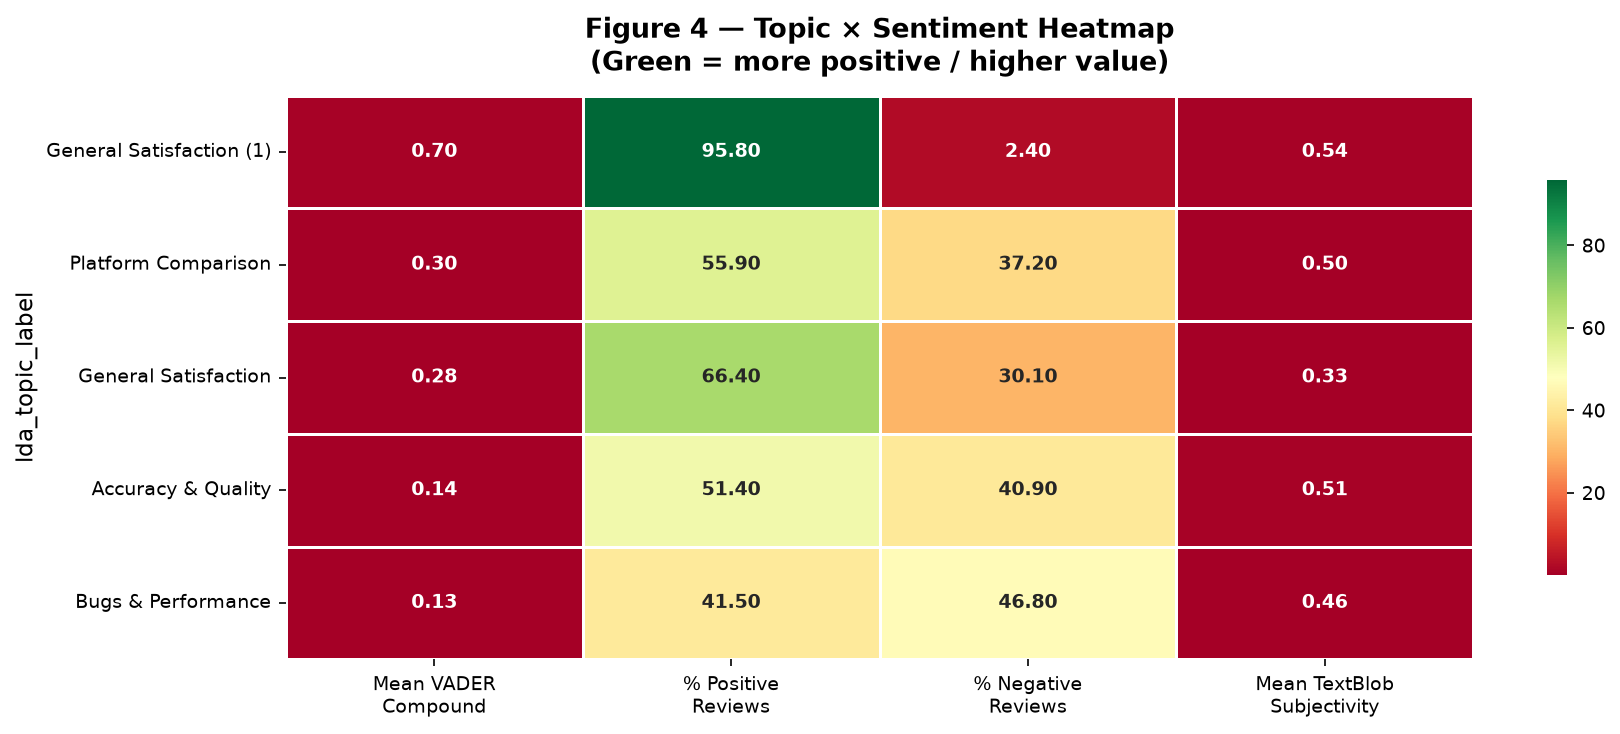

In [20]:
# ── Figure 4: Topic sentiment heatmap ─────────────────────────────────────────
_ts = topic_sent.set_index("lda_topic_label")[
    ["mean_vader", "pct_pos", "pct_neg", "mean_subj"]
].rename(columns={
    "mean_vader" : "Mean VADER\nCompound",
    "pct_pos"    : "% Positive\nReviews",
    "pct_neg"    : "% Negative\nReviews",
    "mean_subj"  : "Mean TextBlob\nSubjectivity",
})

fig, ax = plt.subplots(figsize=(12, max(5, len(_ts) * 0.55 + 2)))
sns.heatmap(
    _ts, ax=ax, annot=True, fmt=".2f",
    annot_kws={"size": 9, "weight": "bold"},
    cmap="RdYlGn", linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Figure 4 — Topic × Sentiment Heatmap\n"
             "(Green = more positive / higher value)",
             fontweight="bold", pad=12)
ax.tick_params(axis="y", labelsize=9, rotation=0)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
save_fig("fig_nb04_04_topic_sentiment_heatmap.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_05_platform_topic_heatmap.png


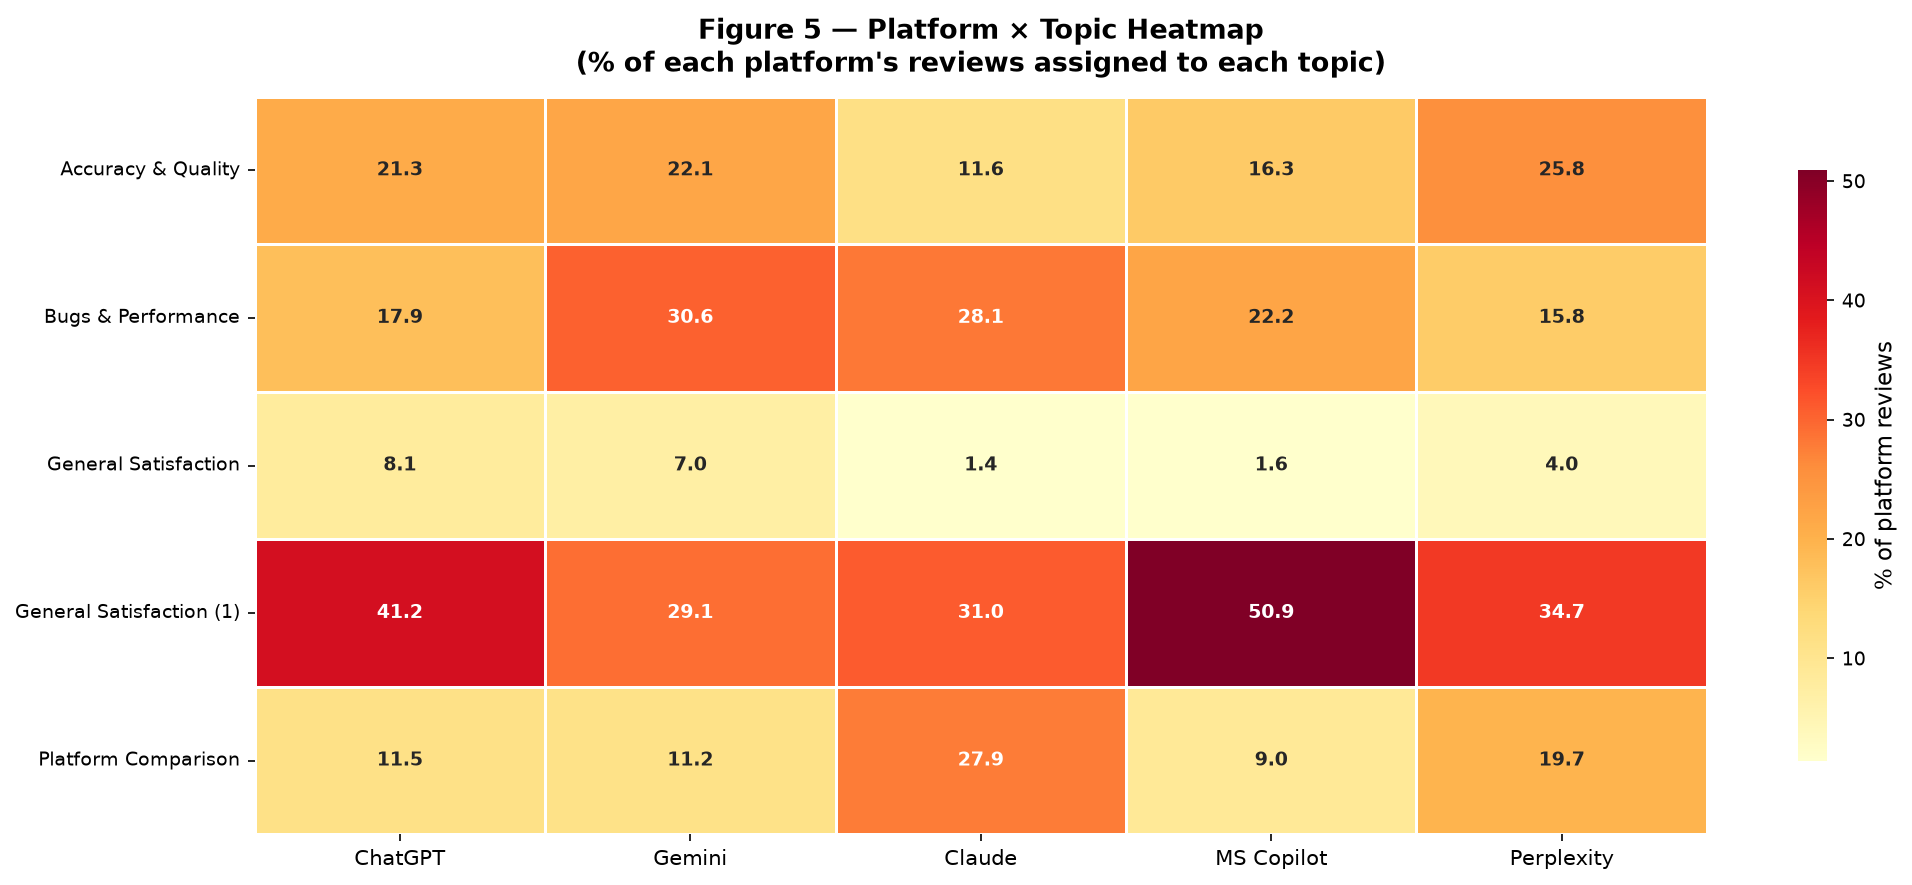

In [21]:
# ── Figure 5: Platform-topic heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, max(6, len(pivot_pct) * 0.6 + 2)))
sns.heatmap(
    pivot_pct, ax=ax,
    annot=True, fmt=".1f",
    annot_kws={"size": 9, "weight": "bold"},
    cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "% of platform reviews"},
)
ax.set_title("Figure 5 — Platform × Topic Heatmap\n"
             "(% of each platform's reviews assigned to each topic)",
             fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10, rotation=0)
ax.tick_params(axis="y", labelsize=9, rotation=0)
plt.tight_layout()
save_fig("fig_nb04_05_platform_topic_heatmap.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_06_positive_topic_ranking.png


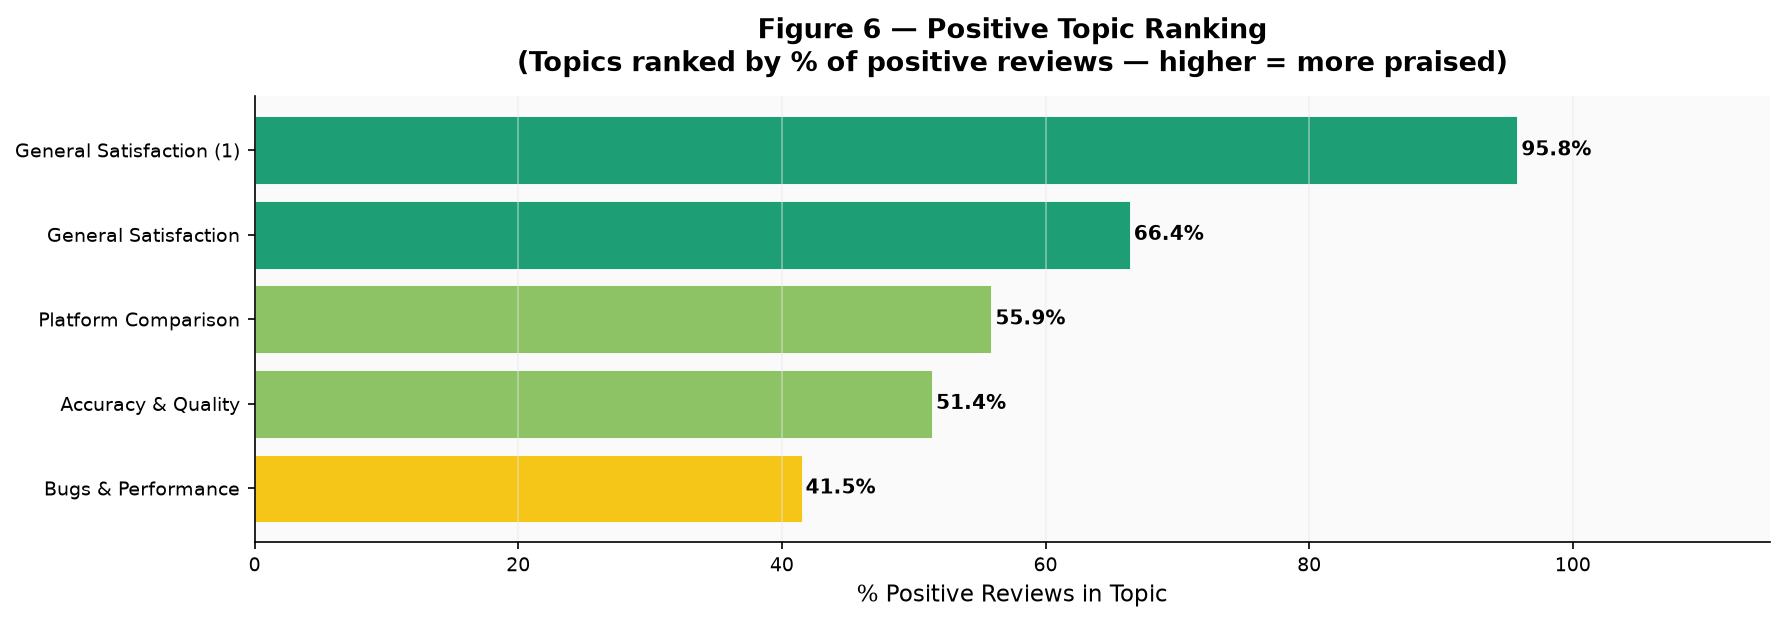

In [22]:
# ── Figure 6: Positive topic ranking ──────────────────────────────────────────
_pos_ts = topic_sent.sort_values("pct_pos", ascending=True).tail(best_k)
fig, ax = plt.subplots(figsize=(12, max(4, len(_pos_ts)*0.55+1.5)))
colors6 = ["#1D9E75" if v >= 60 else "#8DC265" if v >= 45 else "#F5C518"
           for v in _pos_ts["pct_pos"]]
bars = ax.barh(_pos_ts["lda_topic_label"], _pos_ts["pct_pos"],
               color=colors6, edgecolor="white", linewidth=0.4)
for bar, val in zip(bars, _pos_ts["pct_pos"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9.5, fontweight="bold")
ax.set_xlabel("% Positive Reviews in Topic")
ax.set_title("Figure 6 — Positive Topic Ranking\n"
             "(Topics ranked by % of positive reviews — higher = more praised)",
             fontweight="bold", pad=12)
ax.set_xlim(0, _pos_ts["pct_pos"].max() * 1.20)
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
save_fig("fig_nb04_06_positive_topic_ranking.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_07_negative_topic_ranking.png


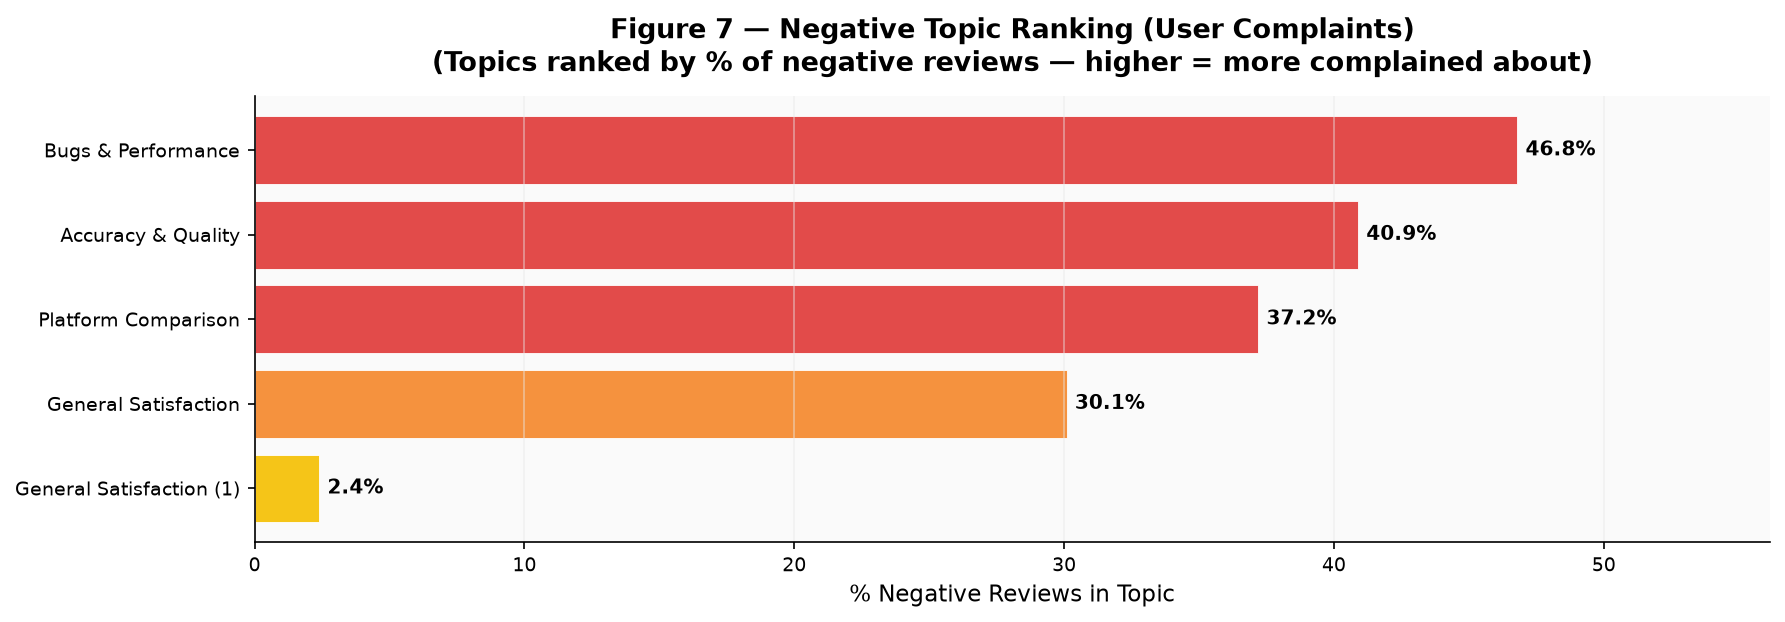

In [23]:
# ── Figure 7: Negative topic ranking (complaints) ─────────────────────────────
_neg_ts = topic_sent.sort_values("pct_neg", ascending=False).head(best_k)
fig, ax = plt.subplots(figsize=(12, max(4, len(_neg_ts)*0.55+1.5)))
colors7 = ["#E24B4A" if v >= 35 else "#F5923E" if v >= 25 else "#F5C518"
           for v in _neg_ts["pct_neg"]]
bars = ax.barh(_neg_ts["lda_topic_label"][::-1], _neg_ts["pct_neg"][::-1],
               color=colors7[::-1], edgecolor="white", linewidth=0.4)
for bar, val in zip(bars, _neg_ts["pct_neg"][::-1].values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9.5, fontweight="bold")
ax.set_xlabel("% Negative Reviews in Topic")
ax.set_title("Figure 7 — Negative Topic Ranking (User Complaints)\n"
             "(Topics ranked by % of negative reviews — higher = more complained about)",
             fontweight="bold", pad=12)
ax.set_xlim(0, _neg_ts["pct_neg"].max() * 1.20)
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
save_fig("fig_nb04_07_negative_topic_ranking.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb04_08_topic_dashboard.png


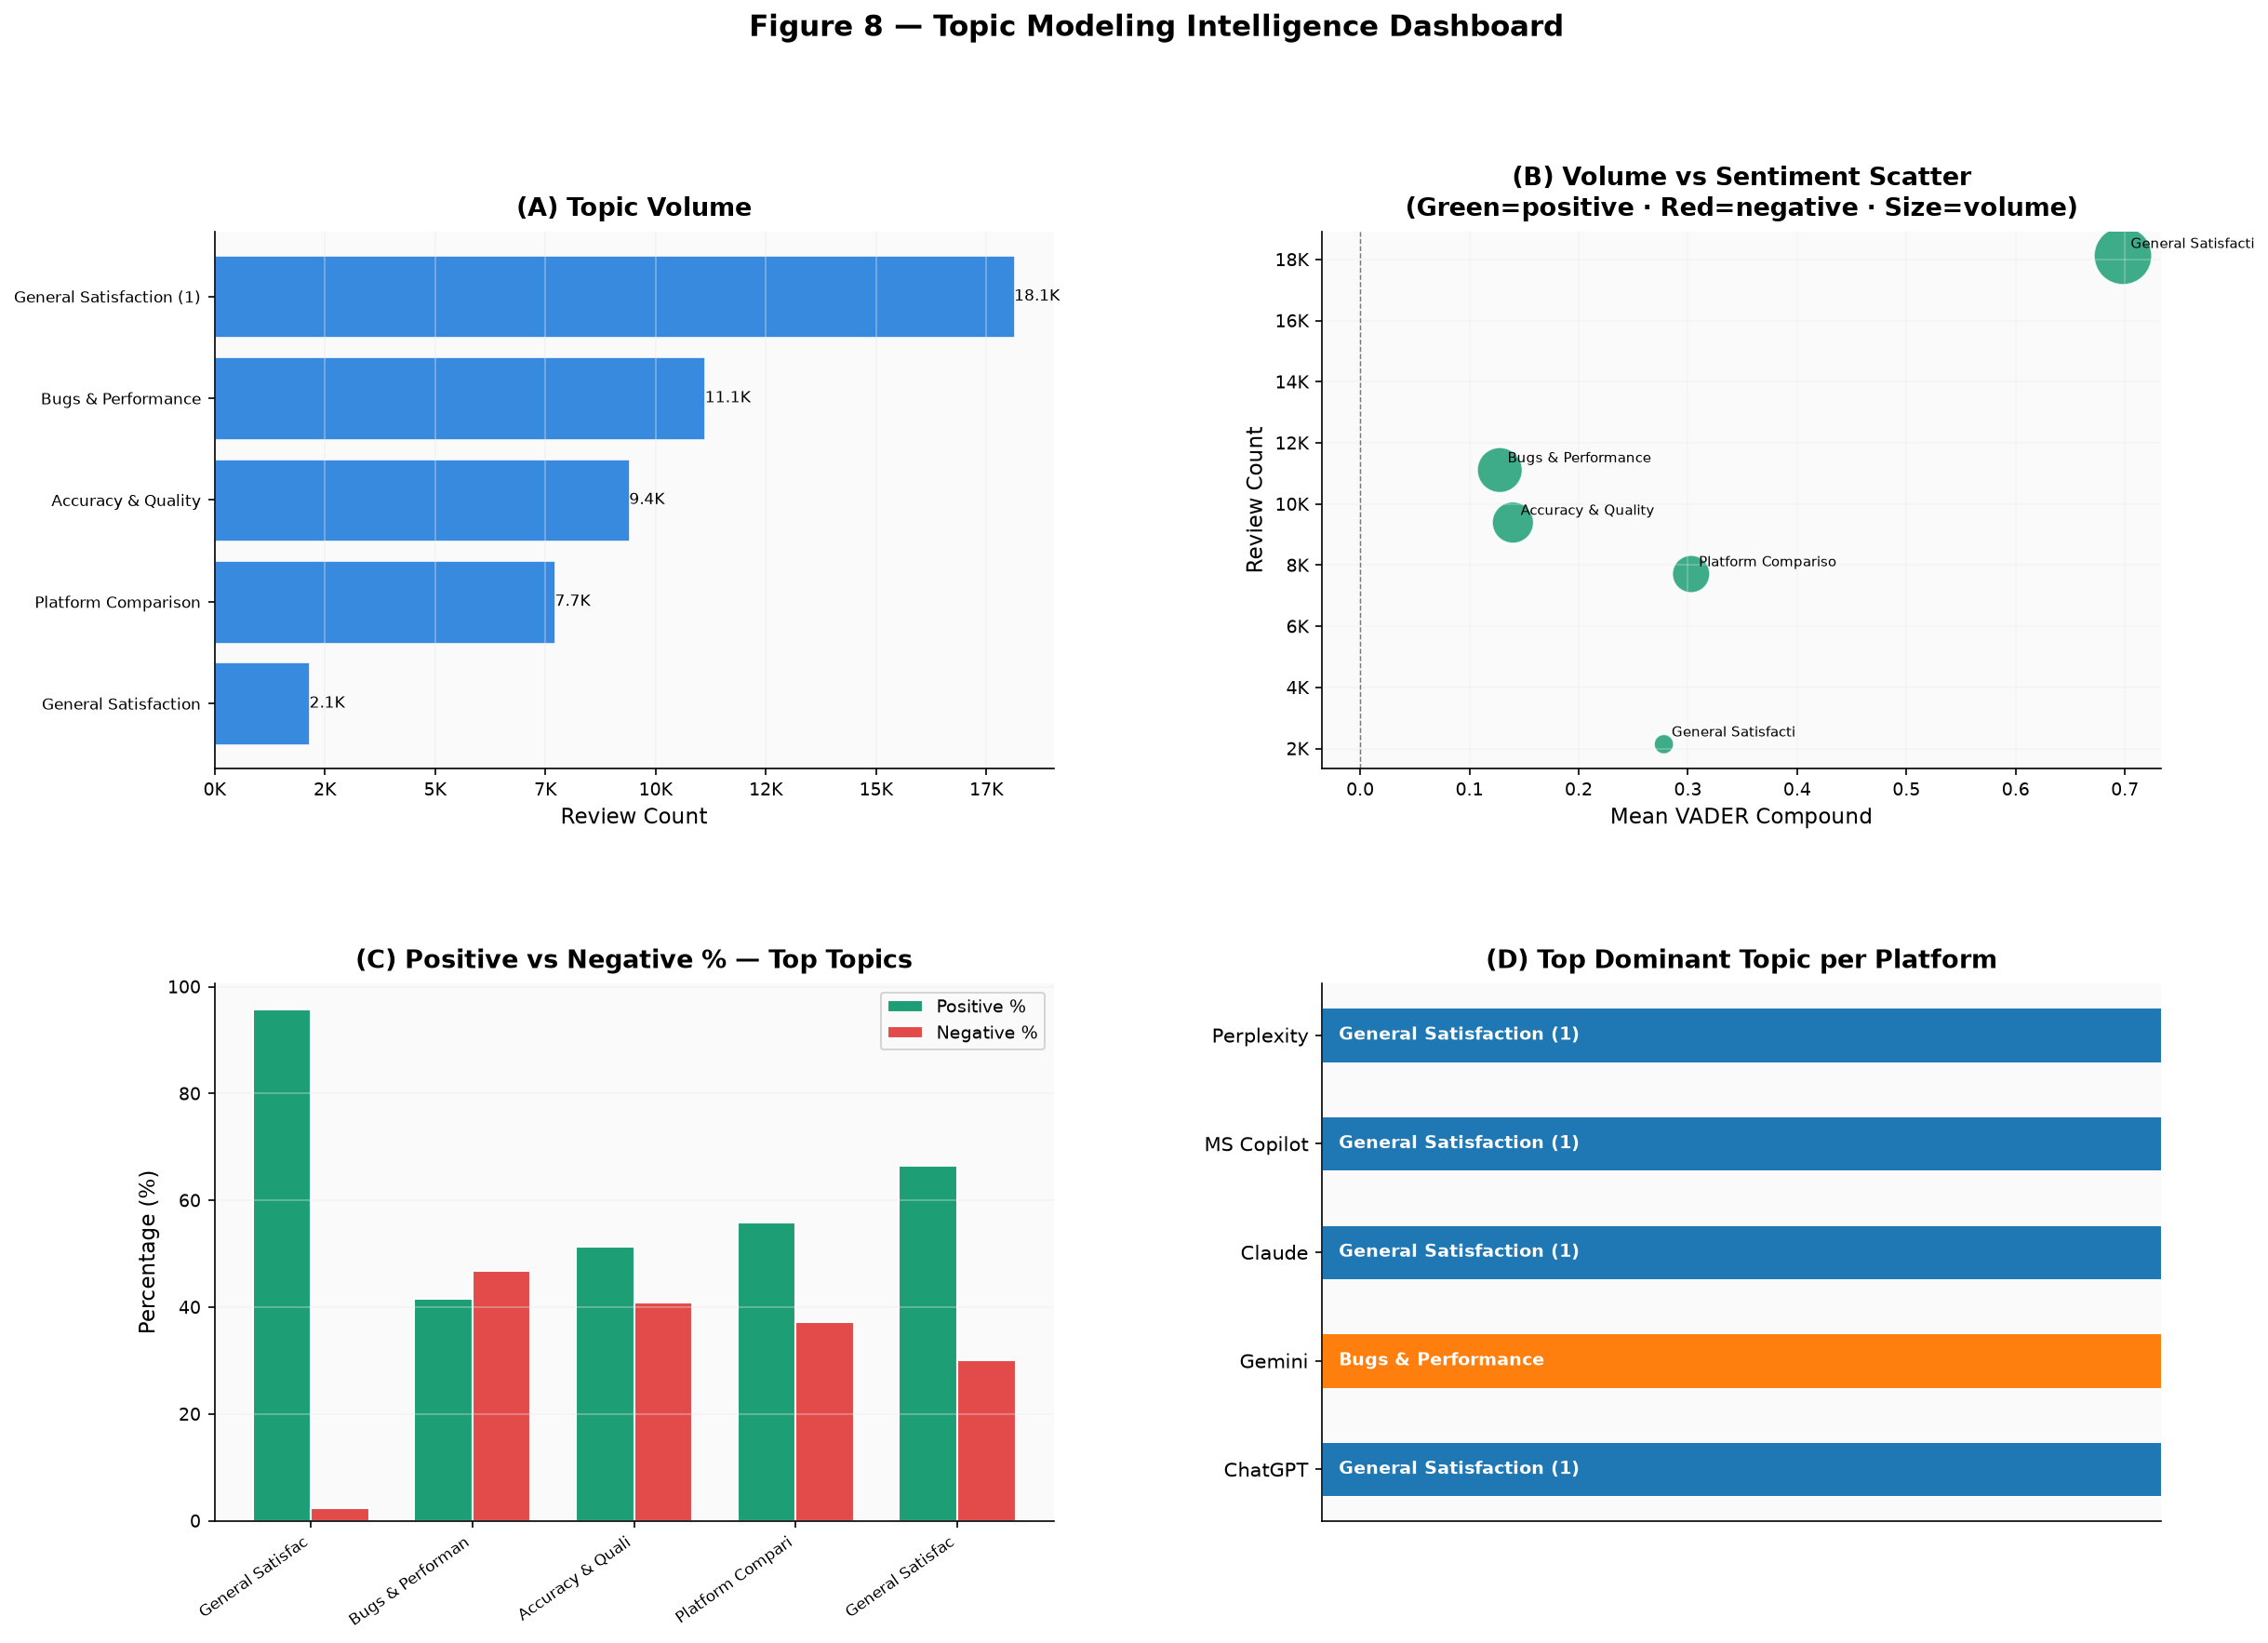

In [24]:
# ── Figure 8: Topic dashboard (4-panel composite) ─────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Panel A: Topic volume (review count per topic)
_vol = topic_summary_df.sort_values("review_count", ascending=True)
_vol_colors = ["#378ADD"] * len(_vol)
ax1.barh(_vol["topic_label"], _vol["review_count"],
         color=_vol_colors, edgecolor="white", linewidth=0.3)
for i, row in _vol.iterrows():
    ax1.text(row["review_count"] + 10,
             _vol.index.tolist().index(i),
             f"{row['review_count']/1000:.1f}K", va="center", fontsize=8)
ax1.set_xlabel("Review Count")
ax1.set_title("(A) Topic Volume", fontweight="bold", pad=8)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))
ax1.grid(axis="x", alpha=0.4)
ax1.tick_params(axis="y", labelsize=8)

# Panel B: Topic sentiment scatter (volume vs sentiment)
_sc = topic_summary_df.copy()
scatter_colors = ["#1D9E75" if v > 0.1 else "#E24B4A" if v < -0.05 else "#F5C518"
                  for v in _sc["mean_vader"]]
ax2.scatter(_sc["mean_vader"], _sc["review_count"],
            s=[max(30, c/20) for c in _sc["review_count"]],
            c=scatter_colors, alpha=0.85, edgecolors="white", linewidth=1)
for _, row in _sc.iterrows():
    short_lbl = row["topic_label"][:18]
    ax2.annotate(short_lbl,
                 xy=(row["mean_vader"], row["review_count"]),
                 xytext=(4, 4), textcoords="offset points", fontsize=7)
ax2.axvline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
ax2.set_xlabel("Mean VADER Compound")
ax2.set_ylabel("Review Count")
ax2.set_title("(B) Volume vs Sentiment Scatter\n"
              "(Green=positive · Red=negative · Size=volume)",
              fontweight="bold", pad=8)
ax2.grid(alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x/1000)}K"))

# Panel C: Stacked positive/negative % per topic
_top5_vol = topic_summary_df.nlargest(min(7, len(topic_summary_df)), "review_count")
x3 = np.arange(len(_top5_vol))
w3 = 0.36
ax3.bar(x3 - w3/2, _top5_vol["pct_positive"], width=w3,
        color="#1D9E75", label="Positive %", edgecolor="white")
ax3.bar(x3 + w3/2, _top5_vol["pct_negative"], width=w3,
        color="#E24B4A", label="Negative %", edgecolor="white")
ax3.set_xticks(x3)
ax3.set_xticklabels(
    [lbl[:16] for lbl in _top5_vol["topic_label"]],
    rotation=35, ha="right", fontsize=8
)
ax3.set_ylabel("Percentage (%)")
ax3.set_title("(C) Positive vs Negative % — Top Topics",
              fontweight="bold", pad=8)
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.4)

# Panel D: Platform-topic top-1 dominance
dominant_topic = {}
for app in APP_ORDER:
    sub = df[(df["App"] == app) & (df["lda_topic_id"] >= 0)]
    if len(sub) > 0:
        dominant_topic[APP_LABELS[app]] = sub["lda_topic_label"].value_counts().idxmax()

topic_uniq = list(dict.fromkeys(dominant_topic.values()))
cmap4      = plt.cm.tab10.colors
topic_cidx = {t: i for i, t in enumerate(topic_uniq)}
y4         = np.arange(len(dominant_topic))
bar_colors4 = [cmap4[topic_cidx[t] % 10] for t in dominant_topic.values()]
ax4.barh(list(dominant_topic.keys()), [1]*len(dominant_topic),
         color=bar_colors4, edgecolor="white", linewidth=0.5, height=0.5)
for i, (plat, topic) in enumerate(dominant_topic.items()):
    ax4.text(0.02, i, topic[:30], va="center", fontsize=9, fontweight="bold",
             color="white")
ax4.set_xlim(0, 1)
ax4.set_title("(D) Top Dominant Topic per Platform",
              fontweight="bold", pad=8)
ax4.set_xticks([])
ax4.tick_params(axis="y", labelsize=10)

plt.suptitle("Figure 8 — Topic Modeling Intelligence Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
save_fig("fig_nb04_08_topic_dashboard.png")
plt.show()

---
## 💾 Section 10 — Export Outputs

Saving all outputs produced by this notebook.

In [25]:
print("Saving outputs...")
_t0 = time.time()

# ── Parquet ────────────────────────────────────────────────────────────────────
df.to_parquet(OUT_PARQ, index=False, engine="pyarrow")
_ps = os.path.getsize(OUT_PARQ) / 1e6
print(f"  ✅  reviews_topics.parquet  ({_ps:.1f} MB)")

# ── CSV ────────────────────────────────────────────────────────────────────────
df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
_cs = os.path.getsize(OUT_CSV) / 1e6
print(f"  ✅  reviews_topics.csv      ({_cs:.1f} MB)")

# ── Verify round-trip ─────────────────────────────────────────────────────────
_check = pd.read_parquet(OUT_PARQ)
assert _check.shape == df.shape, "Parquet round-trip shape mismatch!"
print(f"  ✅  Round-trip verified     ({_check.shape[0]:,} × {_check.shape[1]})")

print(f"\n✅  All files saved in {time.time()-_t0:.1f}s")
print()

# ── New columns manifest ───────────────────────────────────────────────────────
new_topic_cols = ["lda_topic_id", "lda_topic_label", "lda_topic_prob",
                  "bertopic_id",  "bertopic_label"]
print("New columns added by NB04:")
for c in new_topic_cols:
    nn  = df[c].notnull().sum()
    lbl = f"({df[c].nunique()} unique values)" if df[c].dtype == object else ""
    print(f"  {c:<28}  non-null={nn:,}  {lbl}")

print()
print("Supporting CSV files:")
for path in [OUT_TOPIC, OUT_BERT]:
    if os.path.exists(path):
        print(f"  ✅  {os.path.basename(path)}  "
              f"({os.path.getsize(path)/1e3:.1f} KB)")
    else:
        print(f"  ⚠   {os.path.basename(path)}  not found")

Saving outputs...
  ✅  reviews_topics.parquet  (14.3 MB)
  ✅  reviews_topics.csv      (31.9 MB)
  ✅  Round-trip verified     (50,000 × 49)

✅  All files saved in 2.3s

New columns added by NB04:
  lda_topic_id                  non-null=50,000  
  lda_topic_label               non-null=50,000  
  lda_topic_prob                non-null=50,000  
  bertopic_id                   non-null=50,000  
  bertopic_label                non-null=50,000  

Supporting CSV files:
  ✅  topic_summary.csv  (0.7 KB)
  ✅  bertopic_topics.csv  (16.6 KB)


---
## 📋 Section 11 — Executive Summary

In [26]:
print("=" * 70)
print("  TOPIC MODELING EXECUTIVE SUMMARY — SENTIMENTCOMPASS NB04")
print("=" * 70)

# ── LDA overview ──────────────────────────────────────────────────────────────
print()
print("── LDA OVERVIEW ─────────────────────────────────────────────────────────")
print(f"  Optimal topic count (k)  : {best_k}")
print(f"  Best coherence score     : {max(coherence_scores):.4f}")
print(f"  Vocabulary size          : {len(dictionary):,} terms")
print(f"  Reviews with topic       : {(df['lda_topic_id'] >= 0).sum():,}")

# ── Most discussed topic ──────────────────────────────────────────────────────
most_discussed = topic_summary_df.iloc[0]
print()
print("── MOST DISCUSSED TOPIC ─────────────────────────────────────────────────")
print(f"  Topic         : {most_discussed['topic_label']}")
print(f"  Review count  : {int(most_discussed['review_count']):,}  "
      f"({most_discussed['pct_of_total']:.1f}% of all reviews)")
print(f"  Sentiment     : VADER mean = {most_discussed['mean_vader']:.4f}")
print(f"  Split         : {most_discussed['pct_positive']:.1f}% positive  "
      f"{most_discussed['pct_negative']:.1f}% negative")
print(f"  Top keywords  : {most_discussed['top_keywords']}")

# ── Most positive and negative topics ─────────────────────────────────────────
most_pos = topic_sent.sort_values("mean_vader", ascending=False).iloc[0]
most_neg = topic_sent.sort_values("mean_vader", ascending=True).iloc[0]
print()
print("── SENTIMENT EXTREMES ───────────────────────────────────────────────────")
print(f"  Most positive topic  : {most_pos['lda_topic_label']}")
print(f"    VADER mean={most_pos['mean_vader']:.4f}  "
      f"Pos={most_pos['pct_pos']:.1f}%  n={int(most_pos['count']):,}")
print()
print(f"  Most negative topic  : {most_neg['lda_topic_label']}")
print(f"    VADER mean={most_neg['mean_vader']:.4f}  "
      f"Neg={most_neg['pct_neg']:.1f}%  n={int(most_neg['count']):,}")

# ── Per-platform findings ─────────────────────────────────────────────────────
print()
print("── PER-PLATFORM TOP TOPIC ───────────────────────────────────────────────")
for app in APP_ORDER:
    sub  = df[(df["App"] == app) & (df["lda_topic_id"] >= 0)]
    if len(sub) == 0:
        continue
    top_topic = sub["lda_topic_label"].value_counts().idxmax()
    top_cnt   = sub["lda_topic_label"].value_counts().max()
    top_pct   = top_cnt / len(sub) * 100
    top_sent  = sub[sub["lda_topic_label"] == top_topic]["vader_compound"].mean()
    print(f"  {APP_LABELS[app]:<14}  {top_topic:<35}  "
          f"{top_pct:.1f}%  vader={top_sent:.3f}")

# ── BERTopic ──────────────────────────────────────────────────────────────────
if BERTOPIC_OK and "bertopic_label" in df.columns:
    n_bert_assigned = (df["bertopic_id"] != -1).sum()
    print()
    print("── BERTOPIC RESULTS ─────────────────────────────────────────────────────")
    print(f"  Reviews assigned (non-outlier) : {n_bert_assigned:,}  "
          f"({n_bert_assigned/len(df)*100:.1f}%)")
    n_topics_found = df[df["bertopic_id"] != -1]["bertopic_id"].nunique()
    print(f"  Unique topics discovered       : {n_topics_found}")
    top_bert = (df[df["bertopic_id"] != -1]["bertopic_label"]
                .value_counts().head(3))
    print(f"  Top 3 BERTopic clusters:")
    for lbl, cnt in top_bert.items():
        print(f"    {lbl:<40}  {cnt:,} reviews")

# ── Business recommendations ──────────────────────────────────────────────────
print()
print("── BUSINESS RECOMMENDATIONS ─────────────────────────────────────────────")
_recs = [
    ("Pricing & Cost concerns appear" if
     any("Pricing" in lbl for lbl in df["lda_topic_label"].unique())
     else "No clear pricing topic found",
     "Consider transparent pricing tiers and free-tier improvements."),
    ("Bug/Performance topic exists" if
     any("Bug" in lbl or "Performance" in lbl for lbl in df["lda_topic_label"].unique())
     else "Stability seems reasonable",
     "Prioritise crash-fix updates — performance bugs drive negative reviews most."),
    ("Accuracy concerns detected" if
     any("Accuracy" in lbl for lbl in df["lda_topic_label"].unique())
     else "Accuracy rarely mentioned",
     "Hallucination reduction and fact-checking features are high-impact investments."),
]
for finding, rec in _recs:
    print(f"  Finding : {finding}")
    print(f"  Action  : {rec}")
    print()

print("=" * 70)
print("  ▶  Next: run the Streamlit Dashboard (dashboard/app.py)")
print("=" * 70)

  TOPIC MODELING EXECUTIVE SUMMARY — SENTIMENTCOMPASS NB04

── LDA OVERVIEW ─────────────────────────────────────────────────────────
  Optimal topic count (k)  : 5
  Best coherence score     : 0.3549
  Vocabulary size          : 2,875 terms
  Reviews with topic       : 48,480

── MOST DISCUSSED TOPIC ─────────────────────────────────────────────────
  Topic         : General Satisfaction (1)
  Review count  : 18,122  (36.2% of all reviews)
  Sentiment     : VADER mean = 0.6982
  Split         : 95.8% positive  2.4% negative
  Top keywords  : best, love, good, help, great, claude, amazing, helpful

── SENTIMENT EXTREMES ───────────────────────────────────────────────────
  Most positive topic  : General Satisfaction (1)
    VADER mean=0.6982  Pos=95.8%  n=18,122

  Most negative topic  : Bugs & Performance
    VADER mean=0.1278  Neg=46.8%  n=11,112

── PER-PLATFORM TOP TOPIC ───────────────────────────────────────────────
  ChatGPT         General Satisfaction (1)             41.2%  va

---
## 📌 Handoff to Dashboard

| Column | Produced here | Dashboard use |
|--------|-------------|---------------|
| `lda_topic_id` | ✅ | Topic filter sidebar |
| `lda_topic_label` | ✅ | Topic heatmap, topic breakdown chart |
| `lda_topic_prob` | ✅ | Topic confidence filter |
| `bertopic_id` | ✅ | BERTopic cluster visualisation |
| `bertopic_label` | ✅ | Semantic topic labels panel |
| `topic_summary.csv` | ✅ | Dashboard data table |

**▶ Proceed to `dashboard/app.py`** — Streamlit multi-page interactive dashboard